# Model Comparison OFF Cells

This notebook compares OFF-cell model fits using LOO/ WAIC criteria.

In [1]:
import arviz as az
from rvm_analysis.plotting import plot_loo_comparison
from pathlib import Path

In [2]:
base_path: Path = Path("../Bayesian_trial_function_fits/models/off_models/")
models = {
    "Linear \n + Exp.": "21_OFF_cells_linear_slope_aggregated",
    "exp": "22_OFF_cells_exp_recovery_aggregated",
    "Exp. \n + Exp.": "24_OFF_cells_double_exp_recovery_aggregated",
    "Mean": "27_mean_func_aggregated_counts"
}

In [3]:
traces = {}
for name,path in models.items():
    full_path = base_path / path / "idata_with_log_liks.nc"
    print(full_path)
    traces[name] = az.from_netcdf(full_path)

..\Bayesian_trial_function_fits\models\off_models\21_OFF_cells_linear_slope_aggregated\idata_with_log_liks.nc
..\Bayesian_trial_function_fits\models\off_models\22_OFF_cells_exp_recovery_aggregated\idata_with_log_liks.nc
..\Bayesian_trial_function_fits\models\off_models\24_OFF_cells_double_exp_recovery_aggregated\idata_with_log_liks.nc
..\Bayesian_trial_function_fits\models\off_models\27_mean_func_aggregated_counts\idata_with_log_liks.nc


In [4]:
df_comp_waic = az.compare(traces,ic='waic')

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_waic (log)', ylabel='ranked models'>

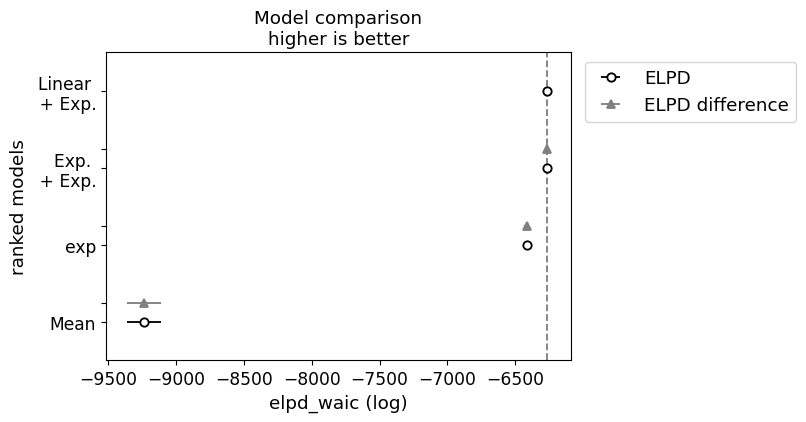

In [5]:
az.plot_compare(df_comp_waic, insample_dev=False)

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

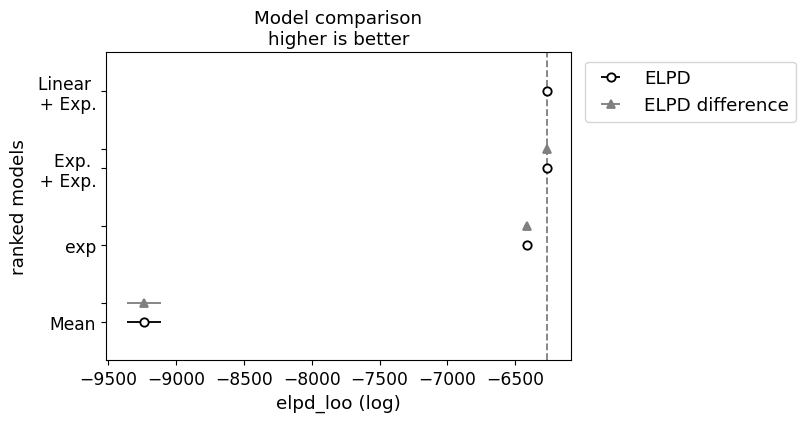

In [6]:
df_comp_loo = az.compare(traces,ic='loo')
az.plot_compare(df_comp_loo, insample_dev=False)

In [7]:
df_comp_waic

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Linear \n + Exp.,0,-6264.942393,4.548525,0.000000,6.927422e-01,20.575938,0.000000,False,log
Exp. \n + Exp.,1,-6267.339524,4.915086,2.397131,3.072578e-01,20.779078,3.525612,False,log
exp,2,-6415.026109,3.890839,150.083716,7.229632e-16,23.623500,17.065780,False,log
Mean,3,-9237.168113,2.900111,2972.225720,0.000000e+00,122.209189,123.886424,False,log


In [8]:
df_comp_loo

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Linear \n + Exp.,0,-6264.953259,4.559390,0.000000,6.940141e-01,20.576095,0.000000,False,log
Exp. \n + Exp.,1,-6267.355049,4.930611,2.401791,3.059862e-01,20.779306,3.525834,False,log
exp,2,-6415.036038,3.900768,150.082779,2.329375e-07,23.623900,17.065873,False,log
Mean,3,-9237.172467,2.904465,2972.219208,0.000000e+00,122.209325,123.886181,False,log


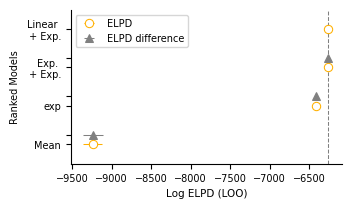

In [9]:
ax = plot_loo_comparison(traces,cell_name="OFF",figsize=(3.5,2),
                         filename="OFF_cell_comparison_LOO_with_mean",
                    basePath="./models/off_models",svg=True,dpi=300,save=True)